# Tohoku Tsunami — Open Elevation Data

This notebook runs the 2011 Tohoku tsunami simulation using **freely available**
global bathymetry/topography instead of the proprietary `Tohoku.pts` file.

Elevation source: **NOAA NCEI Global DEM Mosaic** (GEBCO-based), downloaded via
the ArcGIS ImageServer REST API — no registration or API key required.
- 15 arc-second (~450 m) resolution
- Land topography (SRTM-derived) + ocean bathymetry (GEBCO)
- Coverage: global

Earthquake source: KL random slip field (Karhunen–Loève expansion) via `okada_kl_subfaults`.

Gauge data from https://www.ngdc.noaa.gov/hazard/dart/2011honshu_dart.html

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
import anuga
import okada_kl_subfaults as okl

%matplotlib inline
%load_ext autoreload
%autoreload 2

from matplotlib import rc
rc('animation', html='jshtml')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
try:
    os.chdir('Tohoku')
except:
    pass
print(f'Working directory: {os.getcwd()}')

Working directory: /home/steve/Projects/Tohoku


## Download Elevation Data

Downloads a GeoTIFF covering the simulation domain from the NOAA NCEI Global DEM
Mosaic.  The file is ~19 MB and is skipped on subsequent runs if it already exists.

In [31]:
from download_elevation import download_noaa_dem

# Simulation DEM: covers the ANUGA model domain at full 15 arcsec resolution.
dem_file = 'Tohoku_dem.tif'

if not os.path.exists(dem_file):
    download_noaa_dem(dem_file, resolution_arcsec=15, padding_deg=0.5, verbose=True)
else:
    print(f'Using existing {dem_file}')

# Overview DEM: the whole Japanese archipelago plus DART 21418, used only for
# the locality map below.  Coarse (60 arcsec) since it is never interpolated
# onto the mesh -- keeps the download to ~6 MB.
japan_dem_file = 'Japan_dem.tif'
japan_dem_bounds = (127.0, 150.5, 29.5, 46.5)   # lon_min, lon_max, lat_min, lat_max

if not os.path.exists(japan_dem_file):
    download_noaa_dem(japan_dem_file, bounds=japan_dem_bounds,
                      resolution_arcsec=60, padding_deg=0.0, verbose=True)
else:
    print(f'Using existing {japan_dem_file}')


Using existing Tohoku_dem.tif
Using existing Japan_dem.tif


## Gauge Locations

In [32]:
import utm

class Gauge:
    def __init__(self, long, lat, t1=0.0, t2=1.e10):
        self.lat  = lat
        self.long = long
        self.t1   = t1
        self.t2   = t2
        east, north, zone_no, zone_letter = utm.from_latlon(lat, long, force_zone_number=54)
        self.east        = east
        self.north       = north
        self.zone_no     = zone_no
        self.zone_letter = zone_letter

gauges = {}
gauges[21418] = Gauge(148.694, 38.711)          # DART buoy used for validation
gauges[21401] = Gauge(152.583, 42.617, t1=1800.)
gauges[21413] = Gauge(152.117, 30.515, t1=1800.)
gauges[21419] = Gauge(155.736, 44.455, t1=1800.)
gauges[0]     = Gauge(141.0,   38.0)             # nearshore points
gauges[1]     = Gauge(141.0,   38.125)
gauges[2]     = Gauge(141.0,   38.25)

# Sendai plain: coast to onshore, for the stage / run-up investigation below.
# Keys are names so they can be added to or reordered without touching plots.
sendai_gauges = {
    'Sendai Bay (offshore)': Gauge(141.250, 38.250),
    'Arahama (nearshore)':   Gauge(140.985, 38.210),
    'Gamo':                  Gauge(141.010, 38.265),
    'Shiogama port':         Gauge(141.022, 38.317),
    'Nobiru':                Gauge(141.100, 38.335),
    'Yuriage':               Gauge(140.950, 38.170),
    'Sendai airport':        Gauge(140.930, 38.140),
}

# Inland transect at 38.21 N, from just offshore to above the run-up limit.
transect_lat  = 38.21
transect_lons = [140.995, 140.985, 140.970, 140.955, 140.940,
                 140.925, 140.910, 140.895, 140.880, 140.865, 140.850]
transect_gauges = [Gauge(lon, transect_lat) for lon in transect_lons]


## Fault Parameters (KL slip field)

In [33]:
km = 1000.0

# Fault-plane reference in UTM Zone 54N.  x0/y0 is the centre of the old single
# plane; it is kept because the locality maps below mark it, but the source is
# now anchored at its up-dip (trench) edge instead.
x0 = 720000.0 - 40_000
y0 = 4200000.0

# Up-dip (trench) edge of the rupture, absolute UTM 54N.
xt, yt = 750290.0, 4181170.0

# Split (listric) fault.  The Japan Trench interface is not one plane: the dip
# is 3-5 deg near the trench and steepens to ~12-15 deg by 150 km inboard, and
# tsunami inversions place the large slip *above 10 km* depth (strong-motion
# inversions place it at 25-40 km -- a different quantity).  One uniform-dip
# plane cannot carry both: matching the ~1.2 m of surveyed coastal subsidence
# on a single plane forces slip down dip, which is exactly where it over-loads
# the coast.
#
# Geometry and moment are taken from the literature rather than fitted:
#   * 80 km near-trench segment at 5 deg from 2 km depth   ->  2-9 km
#   * steepening to 15 deg over the deeper 120 km          ->  9-40 km
#   * 200 km total width (published range 200-260 km), 400 km along strike
#   * M0 = 5.3e22 N m, the Global CMT moment (Mw 9.08)
# 90% of the moment sits on the shallow segment: the published 250 x 80 km
# near-trench asperity at ~60 m slip carries essentially the whole earthquake.
M0        = 5.3e22   # N m, Global CMT
f_shallow = 0.90     # fraction of the moment on the near-trench segment

fault_segments = [
    dict(dip=5.0,  width=80 * km, top_depth=2 * km,
         M0=f_shallow * M0,         sig_u=0.20, v0=0.45, sig_v=0.35),
    dict(dip=15.0, width=120 * km,
         M0=(1.0 - f_shallow) * M0, sig_u=0.20, v0=0.45, sig_v=0.35),
]

fault_length = 400 * km
strike, rake = 195.0, 87.0


## Build ANUGA Domain

In [34]:
import project

domain = anuga.create_domain_from_regions(
    project.bounding_polygon,
    boundary_tags={'bottom': [0], 'ocean_east': [1], 'top': [2], 'onshore': [3]},
    maximum_triangle_area=project.res_whole,
    interior_regions=project.interior_regions,
    use_cache=False,
    verbose=False,
)

# ADER second-order solver.  Measured against DE0 (the ANUGA default) and DE1
# at fixed source, DEM and friction: DE_ader2 gave kappa 1.66 and RMS 3.63
# against DE0's 1.71 and 3.74, for identical runtime (88 s each) -- its
# higher-order reconstruction allows a larger stable timestep, which pays for
# the extra work per step.  DE1 (rk2) was worse on every coastal measure and
# cost 129 s.  Set before set_compute_mode(): it resets the limiter betas and
# the timestepping method.
domain.set_flow_algorithm('DE_ader2')

domain.set_epsg(32654)  # WGS 84 / UTM zone 54N
domain.set_collect_max_quantities()
#domain.set_omp_num_threads(12)   # OpenMP is process-wide, not per-domain
domain.set_compute_mode('unified')

xll = domain.geo_reference.xllcorner
yll = domain.geo_reference.yllcorner

print(f'Triangles : {len(domain)}')
print(f'Extent    : {domain.get_extent()}')
print(f'Geo ref   : {domain.geo_reference}')

Triangles : 354946
Extent    : (np.float64(0.0), np.float64(880000.0), np.float64(0.0), np.float64(570000.0))
Geo ref   : (zone=54, easting=420000.000000, northing=3950000.000000, hemisphere=northern, epsg=32654)


## Set Elevation

Two bathymetry/topography sources can be used, selected by `elevation_source`
in the next cell:

- **`'open'`** — the downloaded NOAA NCEI / GEBCO GeoTIFF, 15 arcsec (~450 m).
  ANUGA reads the tif directly via `tif2point_values`, which reprojects the
  domain centroid coordinates (UTM Zone 54N) to EPSG:4326 and looks up
  bilinearly interpolated values from the raster.  Nothing proprietary is
  needed, which is the point of this notebook.
- **`'pts'`** — `Tohoku.pts`, the repository's own bathymetry: 1.34 million
  points at ~150 m spacing, interpolated onto the mesh where it has coverage
  (x 422–899 km, y 3954–4518 km) with the GeoTIFF filling the deep ocean to
  the east, which `Tohoku.pts` does not reach.

The two agree closely on average — over the 330 918 shared cells the mean
difference is +0.03 m — but they differ by 5–12 m RMS exactly where it matters,
on the shelf and the low coastal strip, and they place the coastline slightly
differently.  The effect on the validation is one-sided: heights barely move
(K 0.95 → 0.84, κ 1.72 → 1.70 for a fixed source and friction) but inundation
*extent* improves dramatically — the number of surveyed points the model leaves
dry falls from 64 to 3.  The 450 m DEM cannot resolve the low ground the water
actually crossed.

In [35]:
# 'open' = downloaded GeoTIFF only; 'pts' = overlay Tohoku.pts where it covers.
elevation_source = 'open'

domain.set_quantity('elevation', filename=dem_file, location='centroids', verbose=True)

Elevation = domain.quantities['elevation'].centroid_values

if elevation_source == 'pts':
    from scipy.interpolate import LinearNDInterpolator
    from anuga.geospatial_data.geospatial_data import Geospatial_data

    pts_dem = Geospatial_data('Tohoku.pts')
    interp = LinearNDInterpolator(pts_dem.get_data_points(absolute=True),
                                  np.asarray(pts_dem.get_attributes()))

    # Tohoku.pts carries absolute UTM; ANUGA stores centroids relative to the
    # domain corner, so shift before interpolating.  Cells outside its coverage
    # come back NaN and keep the GeoTIFF value.
    elev_pts = interp(domain.centroid_coordinates[:, 0] + xll,
                      domain.centroid_coordinates[:, 1] + yll)
    covered = np.isfinite(elev_pts)
    Elevation[:] = np.where(covered, elev_pts, Elevation)
    print(f'Tohoku.pts covers {covered.sum()} of {covered.size} cells; '
          f'the GeoTIFF fills the remaining {(~covered).sum()}')

domain.set_name('tohoku_open_dem' if elevation_source == 'open' else 'tohoku_pts_dem')

tide = 0.0
domain.set_quantity('stage', tide)

# Ensure stage >= elevation on land (no water below ground)
Stage = domain.quantities['stage'].centroid_values
Stage[:] = np.maximum(Elevation, Stage)

# Manning friction.  ANUGA defaults to 0.0, which for this model meant nothing
# dissipated the wave between the shelf break and the shore: every source
# tried -- KL, two-segment KL, and five published inversions -- over-predicted
# the surveyed inundation by roughly a factor of two once it was strong enough
# to match DART 21418.
#
# Friction is the second stage of the calibration, and the one knob that leaves
# the far field alone: it moves the coast while the DART peak stays put to
# 0.01 m (friction is negligible in 5700 m of water).  The source above is
# fixed from published values, so nothing in it is tuned against DART.
#
# For that source n = 0.036 gives Aida K = 0.98, kappa = 1.64 and a mean bias
# of +0.11 m, at a DART peak of 1.87 m against 1.87 m observed.  n = 0.033
# gives K 0.92 / kappa 1.63; n = 0.040 gives K 1.09 / kappa 1.68.
#
# It is an effective value standing in for unresolved bed roughness and coastal
# defences on a 450 m DEM, not a measured one -- and it is tied to that DEM:
# elevation_source = 'pts' resolves more of the low coastal strip and wants a
# larger n.
domain.set_quantity('friction', 0.036)

print(f'Elevation source: {elevation_source}')
print(f'Elevation range: {Elevation.min():.1f} m to {Elevation.max():.1f} m')

Applying fitted data to quantity
Elevation source: open
Elevation range: -8012.1 m to 1831.9 m


## Locality Map

The whole Japanese archipelago, showing the Okada fault centre, DART buoy 21418,
the ANUGA model domain, and the red box marking the Tohoku coastal region used
for the inundation close-up further down.


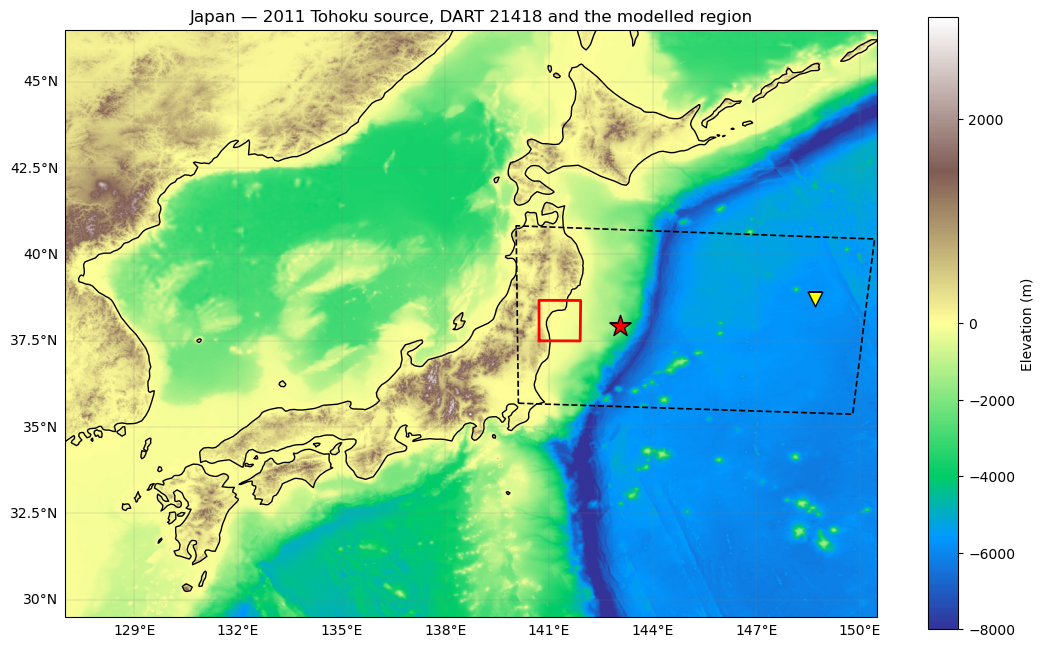

In [36]:
import rasterio
import cartopy.crs as ccrs
from matplotlib.colors import TwoSlopeNorm

# Tohoku coastal region shown in the inundation close-up (UTM Zone 54N metres).
# Defined here so the box drawn on this map and the close-up extent cannot drift.
closeup_extent = [475_000, 580_000, 4_150_000, 4_280_000]


def utm_box(extent, n=50):
    """Densified outline of a UTM rectangle, so it projects correctly."""
    xmin, xmax, ymin, ymax = extent
    xs = np.linspace(xmin, xmax, n)
    ys = np.linspace(ymin, ymax, n)
    x = np.concatenate([xs, np.full(n, xmax), xs[::-1], np.full(n, xmin)])
    y = np.concatenate([np.full(n, ymin), ys, np.full(n, ymax), ys[::-1]])
    return np.append(x, x[0]), np.append(y, y[0])


def add_scalebar(ax, length_km=25, location=(0.07, 0.06), zone=54):
    """Draw a bar of known ground length on a UTM axes (exact: axes are metres)."""
    import matplotlib.patheffects as pe

    xmin, xmax, ymin, ymax = ax.get_extent(crs=ccrs.UTM(zone=zone))
    x = xmin + location[0] * (xmax - xmin)
    y = ymin + location[1] * (ymax - ymin)
    bar = length_km * 1000.0
    stroke = [pe.withStroke(linewidth=3.5, foreground='w')]

    ax.plot([x, x + bar], [y, y], color='k', lw=2.5, solid_capstyle='butt',
            transform=ccrs.UTM(zone=zone), zorder=6, path_effects=stroke)
    ax.text(x + bar / 2, y + 0.018 * (ymax - ymin), f'{length_km} km',
            ha='center', va='bottom', fontsize=9, transform=ccrs.UTM(zone=zone),
            zorder=6, path_effects=stroke)


with rasterio.open(japan_dem_file) as src:
    japan_z = src.read(1)
    b = src.bounds
japan_extent = [b.left, b.right, b.bottom, b.top]


plot_legend = False

fig, ax = plt.subplots(figsize=(11, 7.5), subplot_kw={'projection': ccrs.PlateCarree()})

img = ax.imshow(japan_z, extent=japan_extent, origin='upper',
                transform=ccrs.PlateCarree(), cmap='terrain',
                norm=TwoSlopeNorm(vcenter=0., vmin=-8000., vmax=3000.))
ax.set_extent(japan_extent, crs=ccrs.PlateCarree())

# Tohoku close-up region
bx, by = utm_box(closeup_extent)
ax.plot(bx, by, transform=ccrs.UTM(zone=54), color='red', lw=2,
        label='Inundation close-up')

# ANUGA model domain
poly = np.array(project.bounding_polygon)
ax.plot(np.append(poly[:, 0], poly[0, 0]), np.append(poly[:, 1], poly[0, 1]),
        transform=ccrs.UTM(zone=54), color='k', lw=1.2, ls='--',
        label='ANUGA model domain')

ax.scatter(x0, y0, marker='*', color='red', edgecolor='k', s=260, zorder=5,
           transform=ccrs.UTM(zone=54), label='Fault centre (Okada source)')
ax.scatter(gauges[21418].long, gauges[21418].lat, marker='v', color='yellow',
           edgecolor='k', s=110, zorder=5, transform=ccrs.PlateCarree(),
           label='DART 21418')

if plot_legend:
    ax.annotate('DART 21418', xy=(gauges[21418].long, gauges[21418].lat),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            xytext=(-10, -16), textcoords='offset points', fontsize=8, ha='right')

ax.coastlines(resolution='50m', lw=1.0)
gl = ax.gridlines(draw_labels=True, lw=0.3, color='gray', alpha=0.5)
gl.top_labels = gl.right_labels = False

if plot_legend:
    ax.legend(loc='lower left', framealpha=0.9)
plt.colorbar(img, ax=ax, shrink=0.85, label='Elevation (m)')
plt.title('Japan \u2014 2011 Tohoku source, DART 21418 and the modelled region')
plt.tight_layout()


## View Bathymetry / Topography on the Mesh

Check that the downloaded DEM has interpolated sensibly onto the model mesh.


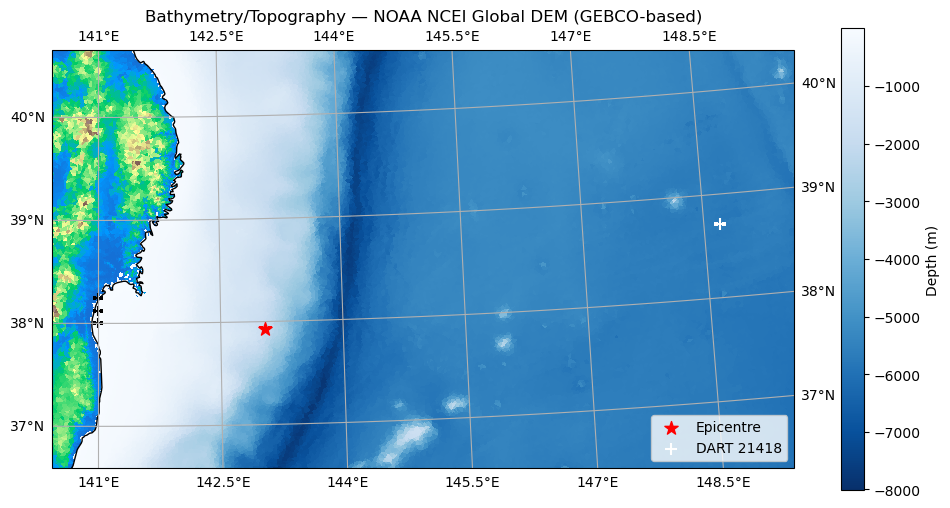

In [37]:
import cartopy.crs as ccrs

dplotter = anuga.Domain_plotter(domain, absolute=True)

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(zone=54)})

md = 0.01  # wet/dry threshold

dplotter.triang.set_mask(dplotter.depth > md)
ax.tripcolor(dplotter.triang, facecolors=dplotter.elev, cmap='terrain', vmin=-200, vmax=2000)

ax.set_extent([450_000, 1_400_000, 4_050_000, 4_500_000], crs=ccrs.UTM(zone=54))
#ax.set_extent([100_000, 1_400_000, 3_900_000, 5_200_000], crs=ccrs.UTM(zone=54))

dplotter.triang.set_mask(dplotter.depth <= md)
img = ax.tripcolor(dplotter.triang, facecolors=dplotter.elev, cmap='Blues_r')
dplotter.triang.set_mask(None)

ax.scatter(x0, y0, marker='*', color='r', s=100, transform=ccrs.UTM(zone=54), label='Epicentre')
ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='w', s=80,
           transform=ccrs.UTM(zone=54), label='DART 21418')
for k in [0, 1, 2]:
    ax.scatter(gauges[k].east, gauges[k].north, marker='+', color='k', s=60,
               transform=ccrs.UTM(zone=54))

ax.gridlines(draw_labels=True)
ax.coastlines(resolution='10m')
ax.legend(loc='lower right')
plt.colorbar(img, ax=ax, shrink=0.6, label='Depth (m)')
plt.title('Bathymetry/Topography — NOAA NCEI Global DEM (GEBCO-based)')
plt.tight_layout()

## Apply Earthquake Deformation

Generate a KL realisation of the slip field and compute the resulting
Okada surface deformation.  Re-run this cell to draw a new sample.

In [38]:
x = domain.centroid_coordinates[:, 0]
y = domain.centroid_coordinates[:, 1]

uE, uN, uZ, slips = okl.split_fault_deformation(
    x, y,
    xt - xll, yt - yll,
    fault_segments,
    length=fault_length,
    strike=strike,
    rake=rake,
)

Elevation = domain.quantities['elevation'].centroid_values
Stage     = domain.quantities['stage'].centroid_values

# Tanioka & Satake (1996).  Where the sea bed slopes, horizontal motion
# displaces water: moving the bed east by uE replaces it with bed that was
# previously to the west, so the water surface feels -uE*dz/dx - uN*dz/dy on
# top of uZ.  The bed itself moves by uZ alone.
#
# This is not a refinement.  uZ scales as slip*sin(dip) -- 0.087 at 5 deg
# against 0.242 at 14 -- while the push term scales with horizontal
# displacement and bed slope, both of which peak at the trench.  For a source
# this shallow the two terms are comparable, and dropping the push costs 64%
# of the DART peak.  Gradients come from the *pre-earthquake* bathymetry, and
# the term applies only where there is water.
elev_q = domain.quantities['elevation']
elev_q.compute_gradients()
push = -(uE * elev_q.x_gradient + uN * elev_q.y_gradient)
push = np.where(Elevation < 0.0, push, 0.0)

Elevation[:] += uZ
Stage[:]     += uZ + push

print(f'peak slip  : {max(s.max() for s in slips):.1f} m   (published near-trench peak 50-70 m)')
print(f'uZ range   : {uZ.min():.2f} m to {uZ.max():.2f} m')
print(f'push range : {push.min():.2f} m to {push.max():.2f} m')
print(f'Stage range: {Stage.min():.2f} m to {Stage.max():.2f} m')


peak slip  : 98.4 m   (published near-trench peak 50-70 m)
uZ range   : -11.10 m to 19.79 m
push range : -2.15 m to 13.52 m
Stage range: -10.32 m to 1831.95 m


## Initial Stage After Deformation

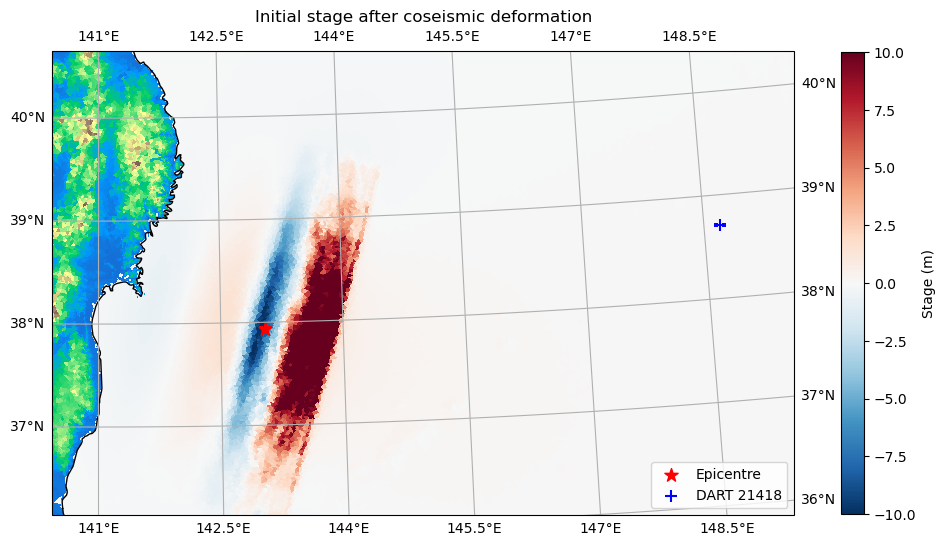

In [39]:
dplotter = anuga.Domain_plotter(domain, absolute=True)

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(zone=54)})

dplotter.triang.set_mask(dplotter.depth > md)
ax.tripcolor(dplotter.triang, facecolors=dplotter.elev, cmap='terrain', vmin=-200, vmax=2000)

dplotter.triang.set_mask(dplotter.depth <= md)
img = ax.tripcolor(dplotter.triang, facecolors=dplotter.stage, cmap='RdBu_r', vmin=-10, vmax=10)
dplotter.triang.set_mask(None)

ax.scatter(x0, y0, marker='*', color='r', s=100, transform=ccrs.UTM(zone=54), label='Epicentre')
ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='b', s=80,
           transform=ccrs.UTM(zone=54), label='DART 21418')

#ax.set_extent([450000, 1000000, 4050000, 4500000], crs=ccrs.UTM(zone=54))
ax.set_extent([450_000, 1_400_000, 4_000_000, 4_500_000], crs=ccrs.UTM(zone=54))
ax.gridlines(draw_labels=True)
ax.coastlines(resolution='10m')
ax.legend(loc='lower right')
plt.colorbar(img, ax=ax, shrink=0.6, label='Stage (m)')
plt.title('Initial stage after coseismic deformation')
plt.tight_layout()

## Boundary Conditions and Evolve

In [40]:
Br = anuga.Reflective_boundary(domain)
Bf = anuga.Flather_external_stage_zero_velocity_boundary(domain, lambda t: tide)

domain.set_boundary({
    'onshore':    Br,
    'bottom':     Bf,
    'ocean_east': Bf,
    'top':        Bf,
})

In [41]:
#from anuga.operators.collect_max_quantities_operator import Collect_max_quantities_operator

#max_min_collector = Collect_max_quantities_operator(domain)
max_collector = domain.max_quantities_operator

In [42]:
import time

min_  = 60.
hour_ = 3600.

# Nothing is sampled in here: every plot below is derived from the .sww, so
# gauge locations can be changed and the figures redrawn without re-evolving.
t0 = time.time()

for t in domain.evolve(yieldstep=2 * min_, finaltime=2.0 * hour_):
    domain.print_timestepping_statistics()

print(f'\nSimulation took {time.time() - t0:.1f} s')



--- GPU Domain (rank 0/1) ---
  Elements: 354946  |  Device: 0  |  GPU-aware MPI: no+==============================================================================+
| GPU interface initialized: 1 MPI rank(s) on 1 GPU(s), OpenMP target offloading
+==============================================================================+

  GPU memory: 165 MB estimated required (device query not available)
  Reflective boundary: 110 edges
  Flather boundary: 434 edges
  Arrays mapped to device 0
[Rank 0] All fractional operators are GPU-safe, no GPU<->CPU sync needed
Time = 0.0000 (sec), steps=0 (0s), elapsed (0s), eta (??), mem=1.89GB
Time = 120.0000 (sec), delta t in [0.73923833, 0.73933817] (s), steps=163 (0s), elapsed (1s), eta (1m:4s), mem=1.89GB
Time = 240.0000 (sec), delta t in [0.73913104, 0.73923834] (s), steps=163 (0s), elapsed (1s), eta (52s), mem=1.89GB
Time = 360.0000 (sec), delta t in [0.73891190, 0.73913126] (s), steps=163 (0s), elapsed (2s), eta (47s), mem=1.89GB
Time = 480.0000 (s

## Read the Results Back from the `.sww`

Everything below reads the `.sww` rather than the live domain, so gauge
positions, snapshot times and map extents can all be changed and the figures
redrawn without re-running the evolve.


In [43]:
sww_file = domain.get_name() + '.sww'
sp = anuga.SWW_plotter(sww_file, absolute=True)
triang = sp.triang

sww_time  = np.asarray(sp.time)
sww_elev  = np.asarray(sp.elev)
sww_stage = np.asarray(sp.stage)
sww_depth = np.asarray(sp.depth)

# SWW_plotter's max_* properties return the max_*_c fields written by
# set_collect_max_quantities(store_to_sww=True), which are true every-timestep
# maxima, and fall back to a max over the stored frames if they are absent.
# For a tsunami the stored fields are much the better choice: scanning frames
# samples the wave at the yieldstep and picks up artificial pulsing.
sww_max_stage = np.asarray(sp.max_stage)
sww_max_depth = np.asarray(sp.max_depth)
sww_max_speed = np.asarray(sp.max_speed)

max_source = ('stored max_*_c (every timestep)' if sp._max_stage_c is not None
              else 'derived from stored frames')

# Kept only to show what frame-scanning would have cost, below.
scan_max_stage = sww_stage.max(axis=0)

md = 0.01                                    # wet/dry threshold


def gauge_cell(gauge):
    """Index of the .sww centroid nearest a gauge, which carries absolute UTM."""
    return int(np.argmin((sp.xc - gauge.east) ** 2 + (sp.yc - gauge.north) ** 2))


def gauge_series(gauge, quantity='stage'):
    """(time, values) at the cell nearest a gauge, straight from the .sww."""
    return sww_time, np.asarray(getattr(sp, quantity))[:, gauge_cell(gauge)]


print(f'{sww_file}: {len(sww_time)} frames, '
      f'{sww_time[0]:.0f}-{sww_time[-1]:.0f} s, {sp.xc.size} cells')
print(f'maxima: {max_source}')


tohoku_open_dem.sww: 61 frames, 0-7200 s, 354946 cells
maxima: stored max_*_c (every timestep)


## Maximum Stage

max wet stage  stored max_*_c (every timestep):  36.03 m
               scanned from frames            :  33.30 m


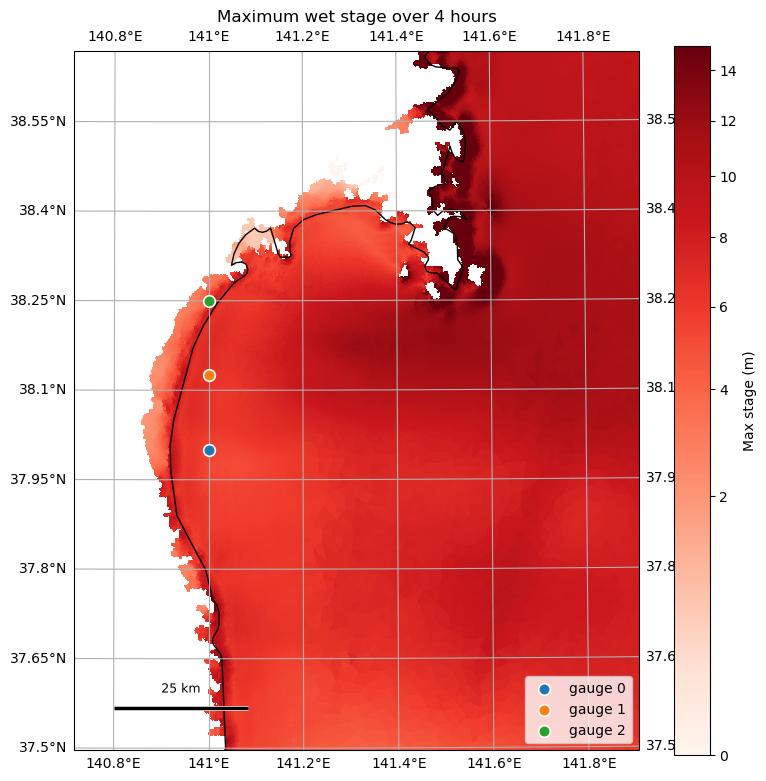

In [44]:
from matplotlib.colors import PowerNorm

wet_max_stage = np.where(sww_max_depth >= md, sww_max_stage, np.nan)

# The .sww only stores yieldsteps, so its maximum can miss a peak that the
# operator (which sees every timestep) caught.  Quantify the gap.
# What the 2-minute frame sampling would have cost, had we scanned instead.
# Mask both the same way, or the comparison picks up dry mountain tops, where
# stage is simply the elevation.
scanned = np.where(sww_max_depth >= md, scan_max_stage, np.nan)
print(f'max wet stage  {max_source:31s}: {np.nanmax(wet_max_stage):6.2f} m')
print(f'               {"scanned from frames":31s}: {np.nanmax(scanned):6.2f} m')

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.UTM(zone=54)})

# Square-root norm: keeps the ~20 m runup peaks unsaturated while retaining
# contrast in the 2-8 m offshore range.
img = ax.tripcolor(triang, facecolors=wet_max_stage,
                   cmap='Reds', norm=PowerNorm(gamma=0.5, vmin=0, vmax=15))

#ax.scatter(x0, y0, marker='*', color='b', s=100, transform=ccrs.UTM(zone=54), label='Epicentre')
#ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='w', s=80,
#           transform=ccrs.UTM(zone=54), label='DART 21418')
for k in [0, 1, 2]:
    ax.scatter(gauges[k].east, gauges[k].north, marker='o', s=70,
               edgecolor='w', linewidth=1.2, zorder=5,
               transform=ccrs.UTM(zone=54), label=f'gauge {k}')

ax.set_extent(closeup_extent, crs=ccrs.UTM(zone=54))   # red box on the locality map
ax.gridlines(draw_labels=True)
ax.coastlines(resolution='10m')
add_scalebar(ax, length_km=25)
ax.legend(loc='lower right')
plt.colorbar(img, ax=ax, shrink=1.0, label='Max stage (m)')
plt.title('Maximum wet stage over 4 hours')
plt.tight_layout()

## Stage Snapshots over the Close-up Region

Actual stage at selected times, read back from the `.sww` output, over the same
Tohoku coastal box outlined in red on the locality map.  The wave leaves the
source to the east and reaches the coast at around 16 minutes.


Text(0.5, 0.91, 'Stage over the Tohoku coast')

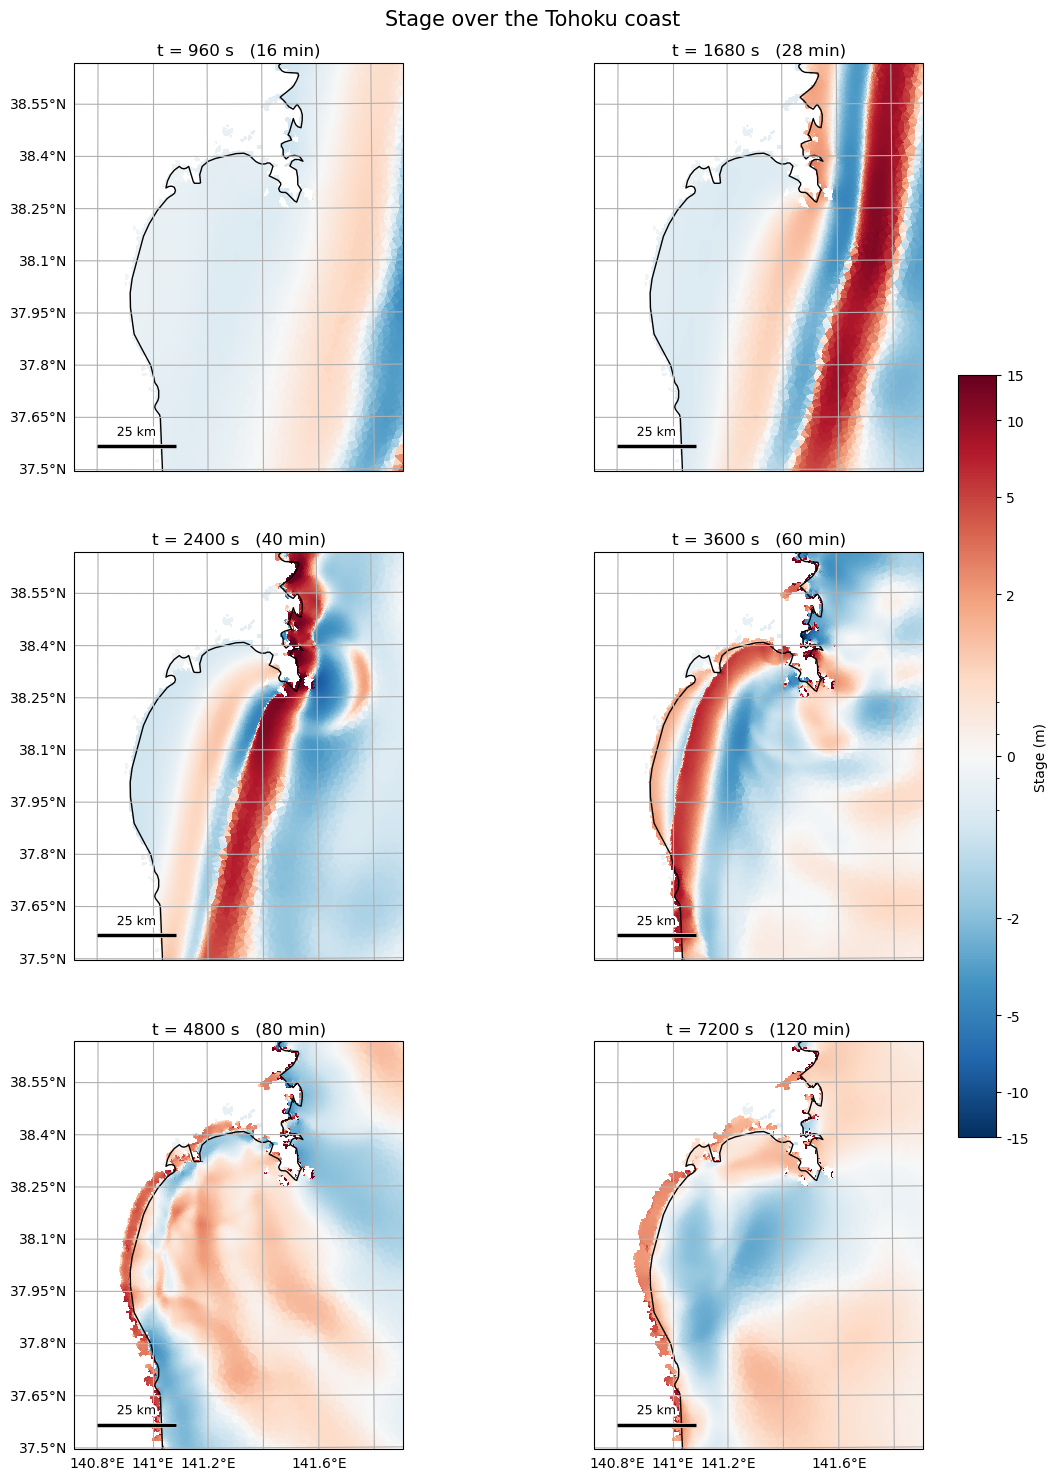

In [45]:
from matplotlib.colors import AsinhNorm

# Initial deformation, first arrival (960 s), then run-up, inundation and the
# long decay out to the end of the run at 4 hours.
snapshot_times = [960., 1680., 2400., 3600., 4800., 7200.]

# Same +/-15 m span and the same square-root-like stretch as the maximum-stage
# figure above, but centred on 0 so the drawdown ahead of each crest is visible.
# A given red is then the same stage in both figures.
norm = AsinhNorm(linear_width=1.0, vmin=-15, vmax=15)

ncol = 2
nrow = int(np.ceil(len(snapshot_times) / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(15, 18),
                         subplot_kw={'projection': ccrs.UTM(zone=54)})
axes = axes.ravel()

for ax, t_snap in zip(axes, snapshot_times):
    f = int(np.argmin(np.abs(sp.time - t_snap)))
    wet_stage = np.where(sp.depth[f] > md, sp.stage[f], np.nan)

    triang.set_mask(sp.depth[f] <= md)
    im = ax.tripcolor(triang, facecolors=wet_stage, cmap='RdBu_r', norm=norm)
    triang.set_mask(None)

    ax.set_extent(closeup_extent, crs=ccrs.UTM(zone=54))
    ax.coastlines(resolution='10m')
    add_scalebar(ax, length_km=25)

    # Label only the outer edge of the grid, or neighbouring panels collide.
    k = list(axes).index(ax)
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = gl.right_labels = False
    gl.left_labels = (k % ncol == 0)
    gl.bottom_labels = (k >= len(snapshot_times) - ncol)

    ax.set_title(f't = {sp.time[f]:.0f} s   ({sp.time[f] / 60:.0f} min)')

for ax in axes[len(snapshot_times):]:
    ax.set_visible(False)

# AsinhNorm brings its own tick locator, so set the ticks after the fact.
ticks = [-15, -10, -5, -2, 0, 2, 5, 10, 15]
cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.55, pad=0.03, label='Stage (m)')
cbar.set_ticks(ticks)
cbar.set_ticklabels([str(t) for t in ticks])
fig.suptitle('Stage over the Tohoku coast', y=0.91, fontsize=15)


## Nearshore Gauge Time Series

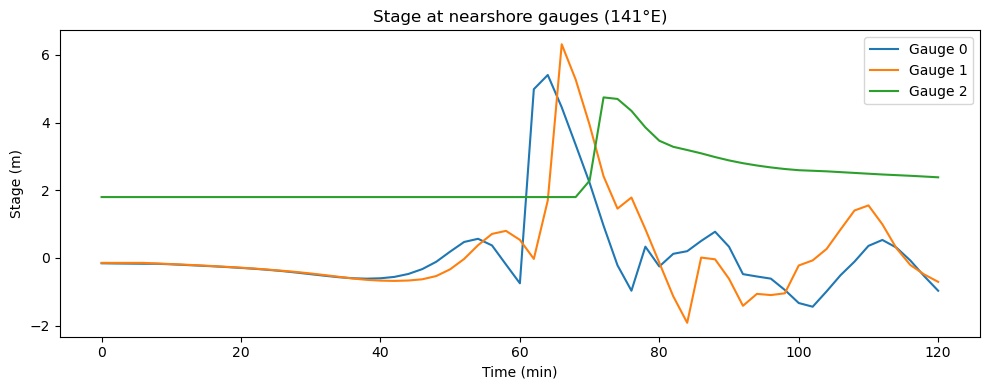

In [46]:
fig, ax = plt.subplots(figsize=(10, 4))

for k in [0, 1, 2]:
    t, stage = gauge_series(gauges[k])
    ax.plot(t / 60, stage, label=f'Gauge {k}')

ax.set_xlabel('Time (min)')
ax.set_ylabel('Stage (m)')
ax.legend()
ax.set_title('Stage at nearshore gauges (141\u00b0E)')
plt.tight_layout()


## Comparison with DART 21418 Observations

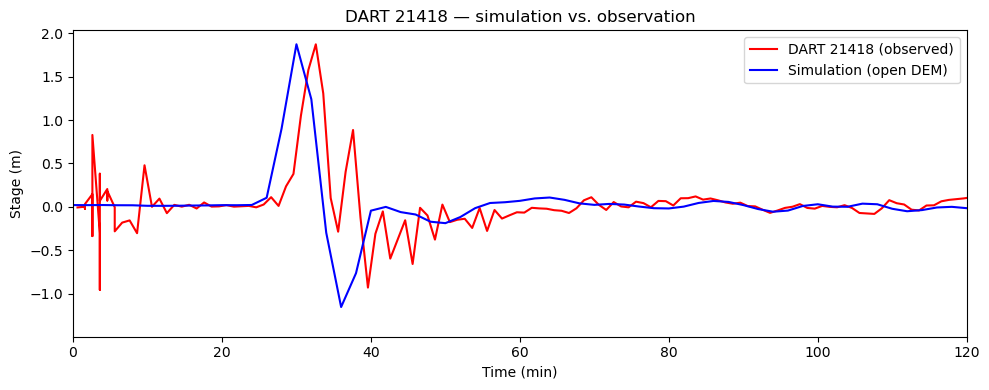

In [47]:
obs = np.loadtxt('21418_notide.txt')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(obs[:, 0] / 60, obs[:, 1], 'r', label='DART 21418 (observed)')
t, stage_21418 = gauge_series(gauges[21418])
ax.plot(t / 60, stage_21418, 'b', label='Simulation (open DEM)')
ax.set_xlim(0, 120)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Stage (m)')
ax.legend()
ax.set_title('DART 21418 — simulation vs. observation')
plt.tight_layout()

## Sendai: Stage and Run-up

The Sendai plain is the flattest, most exposed stretch of this coast.  The
gauges below run from offshore, across the shoreline, to points several
kilometres inland, and the transect at 38.21°N follows the water inland to
the run-up limit.  All of it is read from the `.sww`, so the sites can be
moved and this section re-run on its own.


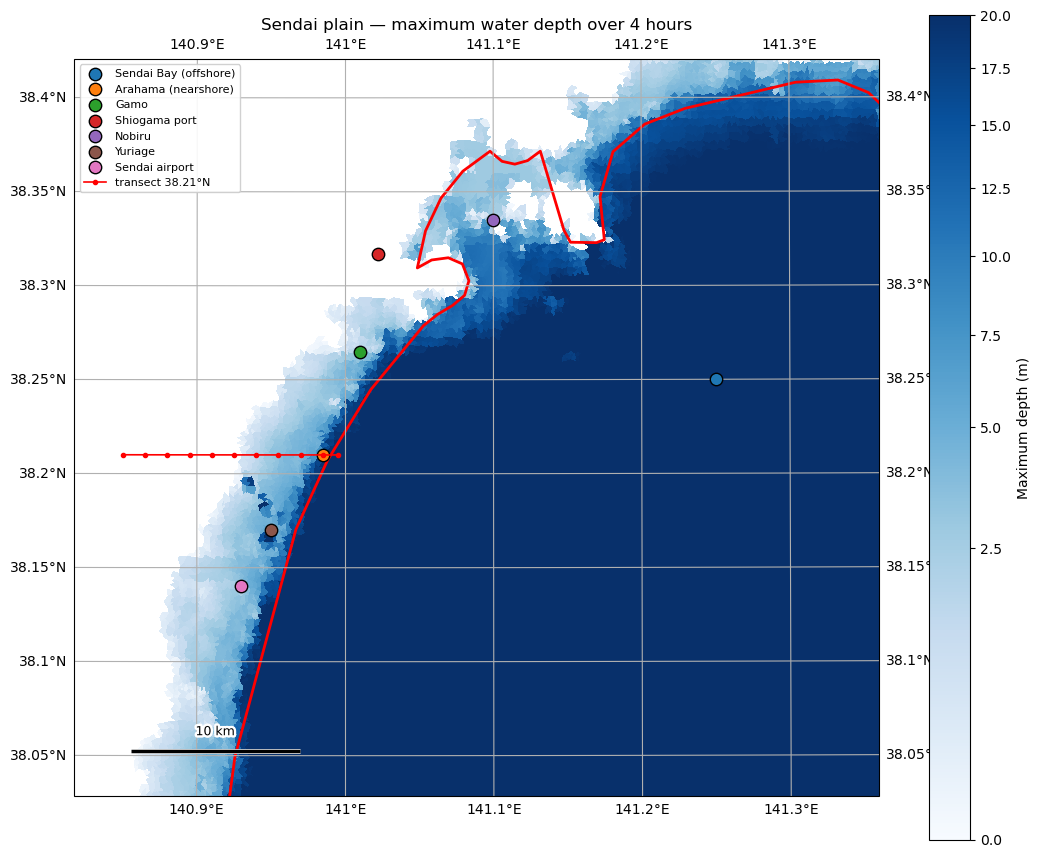

In [48]:
sendai_extent = [484_000, 531_500, 4_209_000, 4_252_500]   # UTM 54N metres

wet_max_depth = np.where(sww_max_depth >= md, sww_max_depth, np.nan)

fig, ax = plt.subplots(figsize=(11, 10), subplot_kw={'projection': ccrs.UTM(zone=54)})

img = ax.tripcolor(triang, facecolors=wet_max_depth, cmap='Blues',
                   norm=PowerNorm(gamma=0.5, vmin=0, vmax=20))

for name, g in sendai_gauges.items():
    ax.scatter(g.east, g.north, marker='o', s=80, edgecolor='k', linewidth=1.0,
               zorder=6, transform=ccrs.UTM(zone=54), label=name)

ax.plot([g.east for g in transect_gauges], [g.north for g in transect_gauges],
        'r.-', lw=1.2, ms=6, zorder=6, transform=ccrs.UTM(zone=54),
        label=f'transect {transect_lat}\u00b0N')

ax.set_extent(sendai_extent, crs=ccrs.UTM(zone=54))
ax.coastlines(resolution='10m', color='r', linewidth=2.0)
ax.gridlines(draw_labels=True)
add_scalebar(ax, length_km=10)
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
plt.colorbar(img, ax=ax, shrink=0.85, label='Maximum depth (m)')
plt.title('Sendai plain \u2014 maximum water depth over 4 hours')
plt.tight_layout()


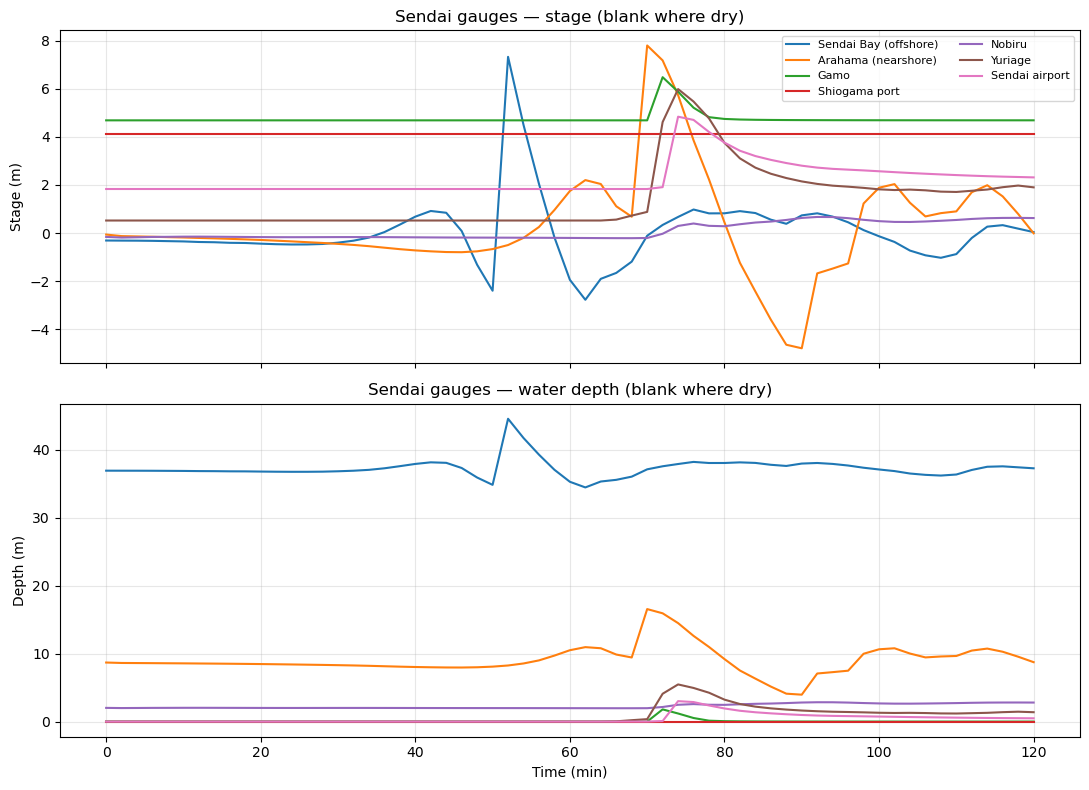

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for name, g in sendai_gauges.items():
    t, stage = gauge_series(g)
    _, depth = gauge_series(g, 'depth')

    # On a dry cell 'stage' is just the ground elevation, which would draw a
    # flat line at the topographic height before the wave arrives.  Blank it.
    wet = depth > md
    #axes[0].plot(t / 60, np.where(wet, stage, np.nan), label=name)
    #axes[1].plot(t / 60, np.where(wet, depth, np.nan), label=name)
    axes[0].plot(t / 60, stage, label=name)
    axes[1].plot(t / 60, depth, label=name)

axes[0].set_ylabel('Stage (m)')
axes[0].set_title('Sendai gauges \u2014 stage (blank where dry)')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(alpha=0.3)

axes[1].set_ylabel('Depth (m)')
axes[1].set_xlabel('Time (min)')
axes[1].set_title('Sendai gauges \u2014 water depth (blank where dry)')
axes[1].grid(alpha=0.3)

plt.tight_layout()


In [50]:
def gauge_summary(g):
    i = gauge_cell(g)
    stage = sww_stage[:, i]
    depth = sww_depth[:, i]
    wet   = depth > md
    # Only wet frames count: on a dry cell 'stage' is just the elevation.
    t_arr     = sww_time[wet][0] / 60 if wet.any() else np.nan
    max_stage = stage[wet].max() if wet.any() else np.nan
    return dict(elev=sww_elev[i], dry0=not wet[0], max_stage=max_stage,
                max_depth=depth.max(), t_arrive=t_arr, ever_wet=wet.any(),
                dist=np.hypot(sp.xc[i] - g.east, sp.yc[i] - g.north))


print(f"{'site':24s}{'elev':>8}{'dry@0':>7}{'max stage':>11}"
      f"{'max depth':>11}{'wet from':>10}{'cell dx':>9}")
print('-' * 80)
for name, g in sendai_gauges.items():
    s = gauge_summary(g)
    print(f"{name:24s}{s['elev']:8.1f}{str(s['dry0']):>7}{s['max_stage']:11.2f}"
          f"{s['max_depth']:11.2f}{s['t_arrive']:10.0f}{s['dist']:9.0f}")

print()
print(f'Inland transect at {transect_lat}\u00b0N')
print(f"{'lon':>10}{'inland km':>11}{'elev':>8}{'max stage':>11}{'max depth':>11}")
print('-' * 51)
coast_east = transect_gauges[1].east
for g in transect_gauges:
    s = gauge_summary(g)
    print(f'{g.long:10.3f}{(coast_east - g.east) / 1000:11.1f}{s["elev"]:8.1f}'
          f'{s["max_stage"]:11.2f}{s["max_depth"]:11.2f}')


site                        elev  dry@0  max stage  max depth  wet from  cell dx
--------------------------------------------------------------------------------
Sendai Bay (offshore)      -37.2  False       7.32      44.52         0      127
Arahama (nearshore)         -8.7  False       7.80      16.54         0       47
Gamo                         4.7   True       6.48       1.79        72       38
Shiogama port                4.1   True        nan       0.00       nan       64
Nobiru                      -2.2  False       0.67       2.84         0       68
Yuriage                      0.5   True       5.98       5.46        66       64
Sendai airport               1.8   True       4.84       3.00        72       76

Inland transect at 38.21°N
       lon  inland km    elev  max stage  max depth
---------------------------------------------------
   140.995       -0.9   -14.6       6.59      21.21
   140.985        0.0    -8.7       7.80      16.54
   140.970        1.3     1.2      

## Validation Against the Surveyed Inundation Heights

Everything so far compares the model with one deep-ocean gauge (DART 21418).
That constrains the wave in 5700 m of water; it says nothing about what the
wave did at the coast.  The 2011 Tohoku Earthquake Tsunami Joint Survey (TTJS)
Group measured that directly: 5907 points along ~2000 km of coast, surveyed by
299 researchers, each with a tide-corrected height.  See `observations/` for
the data and `tsunami_observations.py` for the loader.

Two measurement types are used here:

- **`I` inundation height** — water surface elevation at a trace mark, above
  the astronomical tide when the wave arrived.  Directly comparable with
  ANUGA's `stage` for a run at `tide = 0.0`.
- **`R` run-up height** — the same quantity at the landward limit of the water.

Grades `C` and `D` (beach run-up, marks far from the shoreline, large
measurement error) are dropped: a ~250 m mesh on a 450 m DEM cannot be held to
those.

Read the result with the resolution in mind.  The DEM has no coastal defences,
no river channels and no buildings, and the mesh cell is larger than most of
the features that set a local run-up height.  Agreement point-by-point is not
the goal; the alongshore pattern and the overall bias are.

Data are from the 2011 Tohoku Earthquake Tsunami Joint Survey Group,
release 20121229, <http://www.coastal.jp/ttjt/>.

In [51]:
from scipy.spatial import cKDTree

from tsunami_observations import load_ttjs, in_extent, near

# Inundation ('I') and run-up ('R') points, dropping the C/D grades: those are
# beach run-up and distant marks with large measurement error, and they are the
# ones a 250 m mesh has no hope of reproducing.
survey = load_ttjs(types='IR', reliability='AB')

survey_closeup = in_extent(survey, closeup_extent)
survey_sendai  = in_extent(survey, sendai_extent)

# Survey heights are relative to the astronomical tide when the wave arrived;
# the model's datum is `tide`.  Both are 0.0 here, but keep it explicit so the
# comparison stays right if the run is repeated at a different tide level.
survey_datum_offset = tide

# Only cells the wave actually wet can be compared with a survey mark, so the
# nearest-neighbour search runs over the wet cells alone.
wet = sww_max_depth >= md
wet_tree   = cKDTree(np.column_stack([sp.xc[wet], sp.yc[wet]]))
wet_stage  = sww_max_stage[wet]


def model_height(east, north, radius=1500.0):
    """Modelled maximum stage at the nearest wet cell, NaN beyond `radius`.

    A NaN means the model left that part of the coast dry -- a real failure to
    inundate, not missing data, and it must not be quietly dropped from the
    statistics below.
    """
    east, north = np.atleast_1d(east), np.atleast_1d(north)
    d, j = wet_tree.query(np.column_stack([east, north]),
                          distance_upper_bound=radius)
    hit = np.isfinite(d)
    h = np.full(east.shape, np.nan)
    h[hit] = wet_stage[j[hit]]
    return h, d


print(f'TTJS survey points (type I/R, reliability A/B): {survey["height"].size}')
print(f'  within the close-up extent : {survey_closeup["height"].size}')
print(f'  within the Sendai extent   : {survey_sendai["height"].size}')
print(f'  Sendai: mean {survey_sendai["height"].mean():.2f} m, '
      f'max {survey_sendai["height"].max():.2f} m')

TTJS survey points (type I/R, reliability A/B): 5479
  within the close-up extent : 1768
  within the Sendai extent   : 953
  Sendai: mean 4.46 m, max 19.98 m


### Where the Survey Points Are, and Where the Model Misses

Left: the surveyed heights themselves.  Right: model minus survey at the same
points, on a diverging scale, with crosses where the model left a surveyed
point dry.

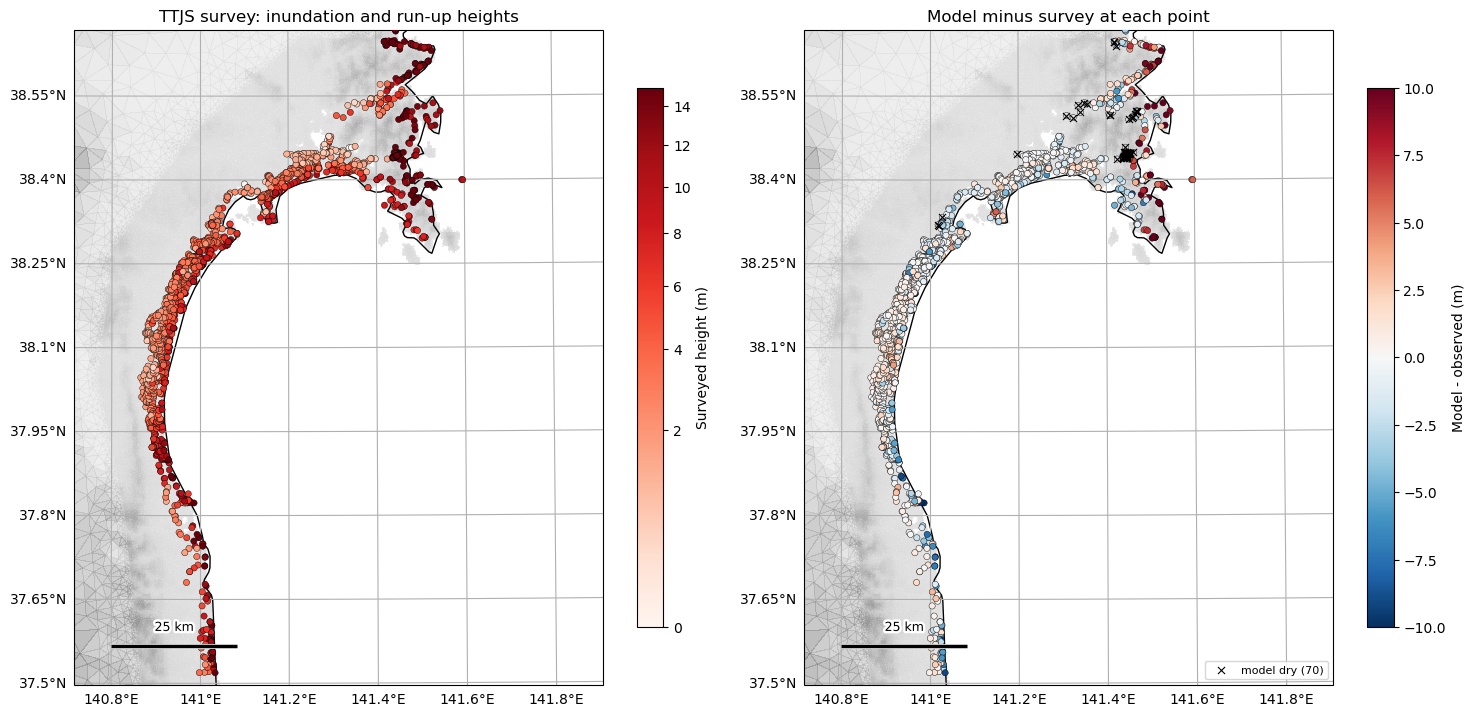

In [52]:
h_closeup, _ = model_height(survey_closeup['east'], survey_closeup['north'])
residual = h_closeup - (survey_closeup['height'] + survey_datum_offset)

fig, axes = plt.subplots(1, 2, figsize=(15, 8),
                         subplot_kw={'projection': ccrs.UTM(zone=54)})

norm_h = PowerNorm(gamma=0.5, vmin=0, vmax=15)          # same as the max-stage map
norm_d = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)

# Muted land/sea backdrop so the survey points carry all the colour.
land = np.where(np.asarray(sp.elev) > 0, np.asarray(sp.elev), np.nan)

panels = [
    (axes[0], survey_closeup['height'], 'Reds', norm_h,
     'Surveyed height (m)', 'TTJS survey: inundation and run-up heights'),
    (axes[1], residual, 'RdBu_r', norm_d,
     'Model - observed (m)', 'Model minus survey at each point'),
]

for ax, values, cmap, norm, label, title in panels:
    ax.tripcolor(triang, facecolors=land, cmap='Greys', vmin=-400, vmax=1500,
                 alpha=0.5)
    img = ax.scatter(survey_closeup['east'], survey_closeup['north'], c=values,
                     cmap=cmap, norm=norm, s=20, edgecolor='k', linewidth=0.3,
                     zorder=5, transform=ccrs.UTM(zone=54))
    ax.set_extent(closeup_extent, crs=ccrs.UTM(zone=54))
    ax.coastlines(resolution='10m')
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = gl.right_labels = False
    add_scalebar(ax, length_km=25)
    ax.set_title(title)
    plt.colorbar(img, ax=ax, shrink=0.7, pad=0.05, label=label)

# Points the model left dry carry no residual; mark them so they are not read
# as agreement.
dry = ~np.isfinite(h_closeup)
axes[1].scatter(survey_closeup['east'][dry], survey_closeup['north'][dry],
                marker='x', s=26, color='k', linewidth=0.8, zorder=6,
                transform=ccrs.UTM(zone=54), label=f'model dry ({dry.sum()})')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()

### Point-by-point Comparison

Aida's (1978) *K* and *&kappa;* are the conventional measures for a tsunami
hindcast: *K* is the geometric mean of observed/modelled — 1.0 is unbiased,
above 1.0 means the model under-predicts — and *&kappa;* is the geometric
standard deviation, the factor within which a typical point falls.  The
Japanese tsunami-assessment guideline asks for 0.95 < K < 1.05 with
&kappa; < 1.45 for a design-grade hindcast; that is a target for a calibrated
source on a 10 m grid, not for a KL draw on a 450 m DEM.

paired points          : 1658 of 1768
model dry at survey pt : 70
Aida K (obs/model)     : 0.98   (1.0 = unbiased, >1 = under-predicted)
Aida kappa             : 1.64   (scatter factor)
mean bias (model-obs)  : +0.11 m
RMS difference         : 3.34 m


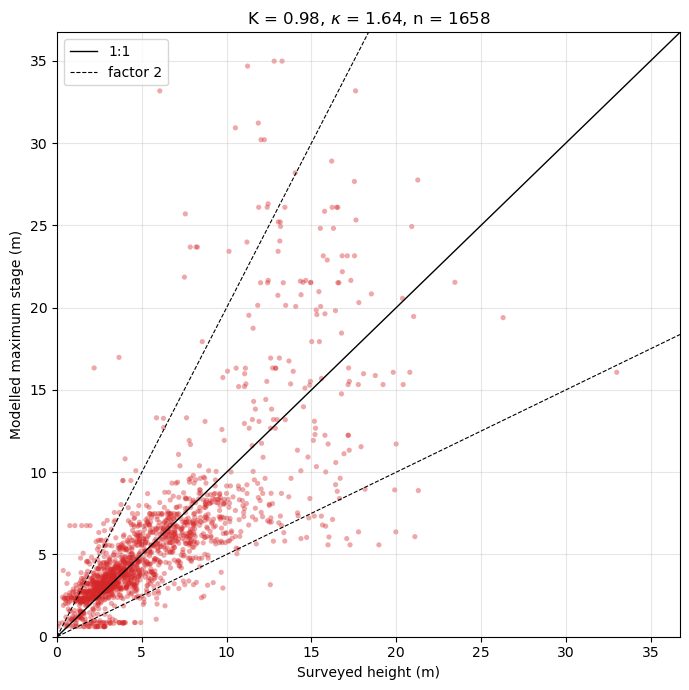

In [53]:
h_model, d_model = model_height(survey_closeup['east'], survey_closeup['north'])
h_obs = survey_closeup['height'] + survey_datum_offset

paired = np.isfinite(h_model) & (h_model > 0) & (h_obs > 0)
n_dry  = int((~np.isfinite(h_model)).sum())

# Aida (1978) K and kappa, the standard tsunami hindcast measures:
# K is the geometric-mean ratio observed/modelled (K > 1 = under-prediction),
# kappa the geometric standard deviation, i.e. the typical scatter factor.
ratio = h_obs[paired] / h_model[paired]
log_K = np.mean(np.log(ratio))
K     = np.exp(log_K)
kappa = np.exp(np.sqrt(np.mean((np.log(ratio) - log_K) ** 2)))

bias = np.mean(h_model[paired] - h_obs[paired])
rms  = np.sqrt(np.mean((h_model[paired] - h_obs[paired]) ** 2))

print(f'paired points          : {paired.sum()} of {h_obs.size}')
print(f'model dry at survey pt : {n_dry}')
print(f'Aida K (obs/model)     : {K:.2f}   (1.0 = unbiased, >1 = under-predicted)')
print(f'Aida kappa             : {kappa:.2f}   (scatter factor)')
print(f'mean bias (model-obs)  : {bias:+.2f} m')
print(f'RMS difference         : {rms:.2f} m')

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(h_obs[paired], h_model[paired], s=14, alpha=0.4,
           edgecolor='none', color='C3')
lim = [0, max(h_obs[paired].max(), h_model[paired].max()) * 1.05]
ax.plot(lim, lim, 'k-', lw=1, label='1:1')
ax.plot(lim, [0.5 * l for l in lim], 'k--', lw=0.8, label='factor 2')
ax.plot(lim, [2.0 * l for l in lim], 'k--', lw=0.8)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Surveyed height (m)')
ax.set_ylabel('Modelled maximum stage (m)')
ax.set_title(f'K = {K:.2f}, $\\kappa$ = {kappa:.2f}, n = {paired.sum()}')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()

### Alongshore Profile

The classic view of this event: tsunami height against latitude.  Both the
survey and the model are reduced to the same 0.1&deg; band statistics, so the
median lines are comparable and the dashed lines show how far the extremes
run apart.

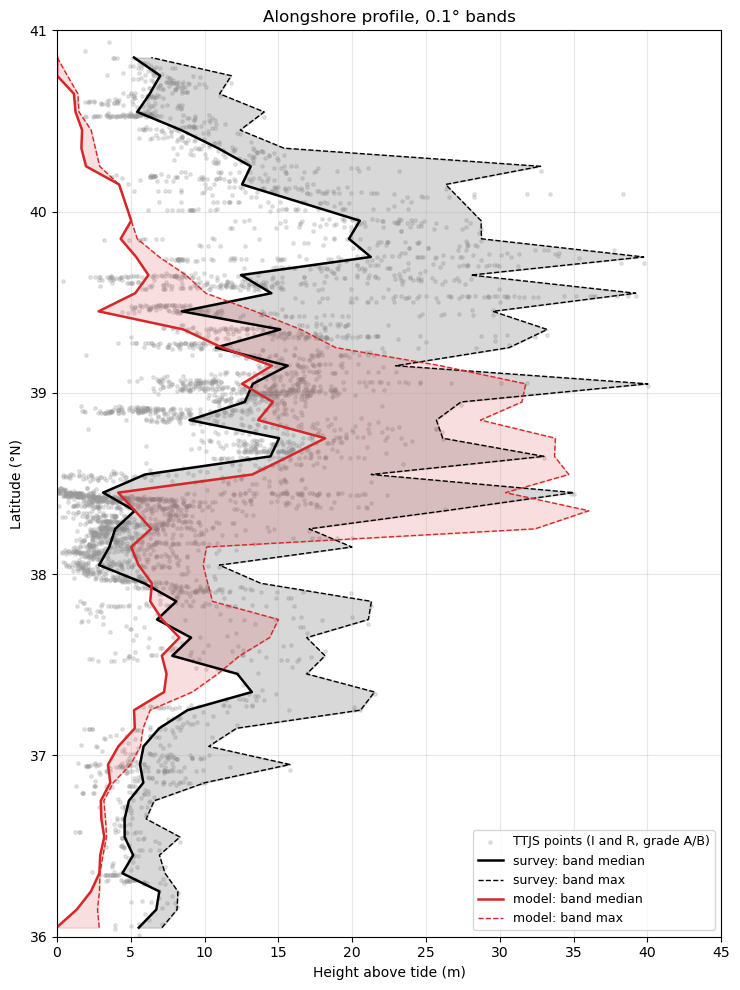

In [55]:
from pyproj import Transformer

to_latlon = Transformer.from_crs('EPSG:32654', 'EPSG:4326', always_xy=True)
cell_lon, cell_lat = to_latlon.transform(sp.xc, sp.yc)

# Band statistics for both, so like is compared with like: a band median and
# the band maximum.  Comparing the model's band maximum against a scatter of
# individual survey points would flatter neither.
lat_edges = np.arange(36.0, 41.0, 0.1)

# "Coastal" model cells: wet, and shallower than 20 m or onshore.  Deeper
# shelf cells would drag the median down towards the open-ocean amplitude.
coastal = wet & (np.asarray(sp.elev) > -20.0)

band_lat, obs_med, obs_max, mod_med, mod_max = [], [], [], [], []
for lo, hi in zip(lat_edges[:-1], lat_edges[1:]):
    m_obs = (survey['lat'] >= lo) & (survey['lat'] < hi)
    m_mod = coastal & (cell_lat >= lo) & (cell_lat < hi)
    if not (m_obs.any() and m_mod.any()):
        continue
    band_lat.append(0.5 * (lo + hi))
    obs_med.append(np.median(survey['height'][m_obs]))
    obs_max.append(survey['height'][m_obs].max())
    mod_med.append(np.median(sww_max_stage[m_mod]))
    mod_max.append(sww_max_stage[m_mod].max())

fig, ax = plt.subplots(figsize=(7.5, 10))

ax.scatter(survey['height'], survey['lat'], s=6, alpha=0.25, color='0.6',
           label='TTJS points (I and R, grade A/B)')
ax.fill_betweenx(band_lat, obs_med, obs_max, color='0.4', alpha=0.25)
ax.plot(obs_med, band_lat, 'k-', lw=1.8, label='survey: band median')
ax.plot(obs_max, band_lat, 'k--', lw=1.0, label='survey: band max')

ax.fill_betweenx(band_lat, mod_med, mod_max, color='C3', alpha=0.15)
ax.plot(mod_med, band_lat, 'C3-', lw=1.8, label='model: band median')
ax.plot(mod_max, band_lat, 'C3--', lw=1.0, label='model: band max')

ax.set_ylim(36.0, 41.0)
ax.set_xlim(0, 45)
ax.set_xlabel('Height above tide (m)')
ax.set_ylabel('Latitude (\u00b0N)')
ax.set_title('Alongshore profile, 0.1\u00b0 bands')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()

### Sendai Plain: Gauges and the Inland Transect

The same sites tabulated above, now against the survey points nearest each one.
The transect is the sharper test — it asks not just how high the water was but
how far inland it reached.

In [56]:
def fmt(value, width, prec=2):
    """Numbers as numbers, and a model that left the site dry as 'dry' --
    a NaN here means no wet cell within the search radius, which is a result,
    not missing data."""
    if value is None or not np.isfinite(value):
        return f'{"dry":>{width}}'
    return f'{value:{width}.{prec}f}'


print(f'{"site":24s}{"n obs":>7}{"obs median":>12}{"obs max":>9}'
      f'{"model":>8}{"model-obs":>11}')
print('-' * 71)
for name, g in sendai_gauges.items():
    s = near(survey, g, radius=3000.)
    hm, _ = model_height(g.east, g.north)
    hm = float(hm[0])
    if s['height'].size:
        med = np.median(s['height'])
        diff = hm - med
        print(f'{name:24s}{s["height"].size:7d}{med:12.2f}{s["height"].max():9.2f}'
              f'{fmt(hm, 8)}{fmt(diff, 11):>11}')
    else:
        print(f'{name:24s}{0:7d}{"-":>12}{"-":>9}{fmt(hm, 8)}{"-":>11}')

print(f'\nInland transect at {transect_lat}°N '
      '(survey points within 2 km of each site)')
print(f'{"lon":>10}{"inland km":>11}{"n obs":>7}{"obs median":>12}{"model":>8}')
print('-' * 48)
coast_east = transect_gauges[1].east
for g in transect_gauges:
    s = near(survey, g, radius=2000.)
    hm, _ = model_height(g.east, g.north)
    hm = float(hm[0])
    med = np.median(s['height']) if s['height'].size else np.nan
    print(f'{g.long:10.3f}{(coast_east - g.east) / 1000:11.1f}{s["height"].size:7d}'
          f'{fmt(med, 12) if s["height"].size else f"{chr(45):>12}"}{fmt(hm, 8)}')

site                      n obs  obs median  obs max   model  model-obs
-----------------------------------------------------------------------
Sendai Bay (offshore)         0           -        -    8.87          -
Arahama (nearshore)          50        5.76    19.98    7.83       2.07
Gamo                        130        4.42    14.72    6.50       2.07
Shiogama port                48        3.11     4.94     dry        dry
Nobiru                        0           -        -    0.67          -
Yuriage                      92        4.58    13.37    5.99       1.41
Sendai airport               70        3.62    12.12    4.90       1.28

Inland transect at 38.21°N (survey points within 2 km of each site)
       lon  inland km  n obs  obs median   model
------------------------------------------------
   140.995       -0.9     16        7.57    6.67
   140.985        0.0     19        6.87    7.83
   140.970        1.3     44        5.39    4.79
   140.955        2.6     65        3.

### What This Configuration Is, and What Would Do Better

The run above takes its source from the literature rather than from fitting:
the Global CMT moment on the published near-trench geometry, with Manning
`n = 0.036` the only tuned number.  It reaches a DART peak of 1.87 m against
1.87 m observed, with K = 0.98 and κ = 1.64 — the first configuration tried
here that satisfies the deep-ocean gauge and the coastal survey at once.

Holding the mesh fixed and varying only the source, the elevation and the
friction (measured with `calibrate_deterministic.py`, which mirrors this
notebook):

| configuration | DART | K | κ | bias | dry |
|---|---|---|---|---|---|
| **split fault, open DEM, n = 0.036** *(this notebook)* | **1.87** | **0.98** | **1.64** | +0.11 | 70 |
| split fault, open DEM, n = 0.033 | 1.87 | 0.92 | **1.63** | +0.39 | 69 |
| KL slip 71, open DEM, n = 0.033 | 1.98 | 0.81 | 1.75 | +1.43 | 65 |
| KL slip 71, `Tohoku.pts`, n = 0.045 †| 1.87 | 1.05 | 1.67 | +0.07 | 45 |
| UCSB3, `Tohoku.pts`, n = 0.05 † | 1.85 | 1.06 | 1.71 | −0.04 | **5** |

*(observed DART peak 1.87 m; `dry` counts surveyed points the model never
wets, out of ~1700.  † measured before the horizontal-push term — and the
`sources/*.pts` inversions carry vertical deformation only, so the term
cannot be applied to them at all.)*

The gap that matters is the last column.  This notebook's configuration wins
on height accuracy but leaves 70 surveyed points dry — places the wave
demonstrably reached that a 450 m DEM cannot represent.  Switching
`elevation_source` to `'pts'` and re-tuning `n` upward takes that to 45, and
the best figure on record is 5.  Extent is a property of the bathymetry, not
of the source.

Three things worth knowing before tuning any of this yourself:

- **The horizontal-push term is not optional for a shallow source.**  Dropping
  it costs this configuration 64% of its DART peak.  `uZ` scales as
  `slip·sin(dip)` — 0.087 at 5°, against 0.242 at 14° — so a near-trench fault
  is nearly three times less efficient per metre of slip in the vertical term
  alone, while the push term scales with horizontal displacement and bed
  slope, both of which peak at the trench.
- **Friction and DEM are coupled.**  `n = 0.036` is calibrated for the 450 m
  DEM; the 150 m `Tohoku.pts` lets more water through and wants a larger `n`.
  Changing one without the other will look like a regression.
- **κ ≈ 1.7 is no longer a floor.**  It held across three sources, two DEM
  resolutions, friction from 0 to 0.05, mesh refinement to 4.7 M cells and
  three solvers — but all of those predate the push term, and this
  configuration reaches 1.63.  Note κ is a geometric standard deviation of
  ratios, so it is *mathematically* invariant under any uniform rescaling of
  the modelled heights: no amplitude knob can ever move it, only a change in
  the shape of the modelled height distribution.

One honesty check the cell above prints: the shallow segment's **peak** slip
comes out near 98 m, against a published near-trench peak of 50–70 m.  The
moment, extent, depth and dip are all published values; the slip
*concentration* is not, and the Gaussian taper is sharper than the real
asperity was.

`CLAUDE.md` carries the full calibration record — the friction curves, all six
sources in `sources/` scored against both gauges, the mesh-resolution and
riverwall tests, and the solver, source-position and DEM hypotheses that were
tested and eliminated while chasing the coast/far-field mismatch that the push
term turned out to explain.
